In [2]:
pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Global settings for visual clarity
%matplotlib inline 
np.random.seed(42) # Ensures the "Robertson Noise" is consistent every time you run it


In [2]:
# 1. Define the Muscle Pool
def create_muscle_pool(n_units, RR, FR):
    # Exponential distribution based on the Fuglevand Model
    thresholds = np.exp(np.log(RR) * np.linspace(0, 1, n_units))
    max_forces = np.exp(np.log(FR) * np.linspace(0, 1, n_units))
    return thresholds, max_forces

n_units = 50
RR = 30      # Recruitment Range (Henneman's Size Principle)
FR = 100     # Force Range (Max Force of the largest unit vs smallest)

#Definiing two muscle pools to compare the effect of recruitment range on force generation

#Pool 1
thresholds1, max_forces = create_muscle_pool(n_units, RR, FR) #First muscle pool with original RR and FR
#Pool 2
thresholds2, max_forces = create_muscle_pool(n_units, RR*2, FR) #Second muscle pool with doubled RR to see the effect on recruitment and force generation

print("Thresholds 1:", thresholds1)
print("Thresholds 2:", thresholds2)
print("Max Forces:", max_forces)


Thresholds 1: [ 1.          1.07187794  1.14892231  1.23150448  1.32002248  1.41490297
  1.51660328  1.62561359  1.74245934  1.86770373  2.00195042  2.14584648
  2.3000855   2.4654109   2.64261955  2.8325656   3.03616457  3.25439781
  3.48831721  3.73905026  4.00780548  4.29587827  4.60465714  4.93563039
  5.29039332  5.67065588  6.07825093  6.51514306  6.98343811  7.48539323
  8.02342785  8.6001353   9.21829528  9.88088733 10.59110513 11.35237191
 12.16835699 13.04299338 13.98049684 14.98538611 16.06250475 17.21704446
 18.45457009 19.78104652 21.20286734 22.7268857  24.36044736 26.11142606
 27.9882615  30.        ]
Thresholds 2: [ 1.          1.08714832  1.18189148  1.28489134  1.39686747  1.51860213
  1.65094576  1.79482292  1.95123873  2.12128592  2.30615243  2.50712976
  2.72562191  2.9631553   3.22138932  3.502128    3.80733259  4.13913525
  4.49985395  4.89200869  5.31833905  5.78182339  6.28569961  6.8334878
  7.42901482  8.07644102  8.78028932  9.54547683 10.37734915 11.2817177

In [3]:


dt = 0.01  # 10ms time steps
time = np.arange(0, 10, dt)
# A sine wave representing a 10-second rhythmic contraction
neural_drive = 20 * np.sin(time * 0.6) + 20


In [4]:
# Model A: Static (No ODE)
def compute_force_static(neural_drive, thresholds, max_forces):
    force_static = []
    for drive in neural_drive:
        # Instant sigmoid activation based on Fuglevand logic
        target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
        force_static.append(np.sum(max_forces * target))
    return force_static

force_static1 = compute_force_static(neural_drive, thresholds1, max_forces)
force_static2 = compute_force_static(neural_drive, thresholds2, max_forces)

In [5]:
# Model B: Dynamic (Liu et al. ODE via Euler Method)
def compute_force_ode(neural_drive, thresholds, max_forces, dt):
    force_ode = []
    current_a = np.zeros(n_units)
    tau = 0.15 # The time constant for activation lag

    for drive in neural_drive:
        target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
        # ODE: da/dt = (target - current) / tau
        da_dt = (target - current_a) / tau
        current_a += da_dt * dt # The Euler Step
        force_ode.append(np.sum(max_forces * current_a))
    return force_ode

force_ode1 = compute_force_ode(neural_drive, thresholds1, max_forces, dt)
force_ode2 = compute_force_ode(neural_drive, thresholds2, max_forces, dt)

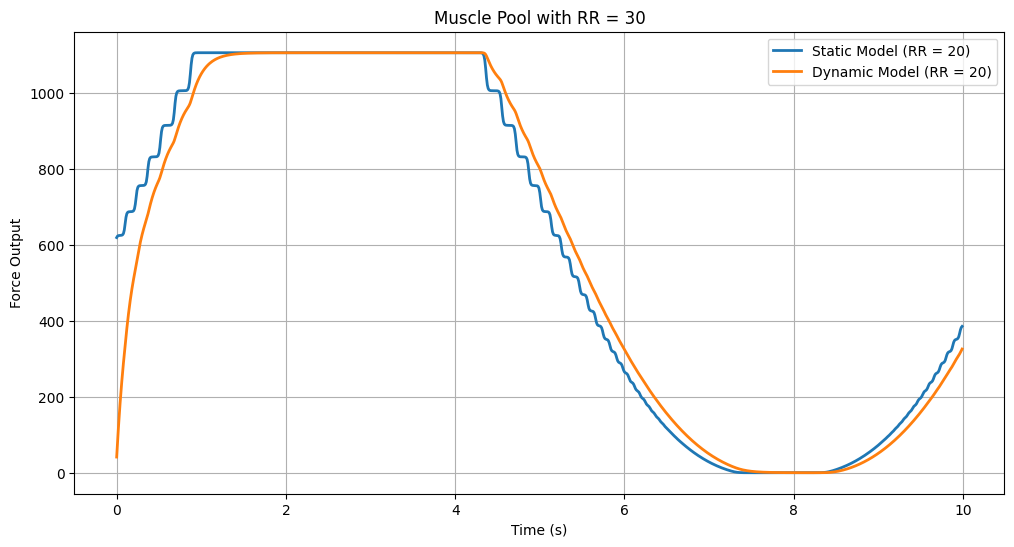

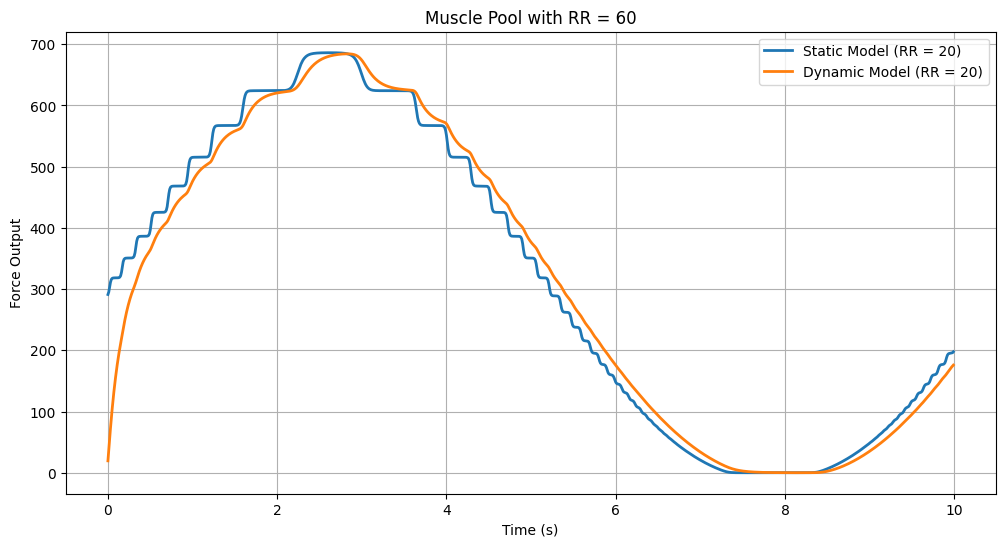

In [6]:
def plot_force_outputs(time, force_static, force_ode, title):

    plt.figure(figsize=(12,6))

    # Static Model
    plt.plot(
        time,
        force_static,
        label='Static Model (RR = 20)',
        linewidth=2
    )

    # Dynamic Model
    plt.plot(
        time,
        force_ode,
        label='Dynamic Model (RR = 20)',
        linewidth=2
    )
    # Labels and Formatting
    plt.xlabel('Time (s)')
    plt.ylabel('Force Output')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting the results for both muscle pools
plot_force_outputs(time, force_static1, force_ode1, 'Muscle Pool with RR = 30')
plot_force_outputs(time, force_static2, force_ode2, 'Muscle Pool with RR = 60')